In [ ]:
import sys
import os

# Check if running in Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🔗 Google Colab detected - mounting Google Drive...")
    from google.colab import drive
    drive.mount('/content/drive')

    # Set working directory to your project folder in Drive
    # OPTION 1: If file is in Drive root
    DATA_PATH = '/content/drive/MyDrive/leukemia_latent_features.csv'

    # OPTION 2: If file is in a project folder (RECOMMENDED)
    # DATA_PATH = '/content/drive/MyDrive/LeukemiaProject/data/processed/leukemia_latent_features.csv'

    # Create models directory in Drive if it doesn't exist
    MODELS_DIR = '/content/drive/MyDrive/LeukemiaProject/models'
    FIGURES_DIR = '/content/drive/MyDrive/LeukemiaProject/reports/figures'
    RESULTS_DIR = '/content/drive/MyDrive/LeukemiaProject/data/processed'

    os.makedirs(MODELS_DIR, exist_ok=True)
    os.makedirs(FIGURES_DIR, exist_ok=True)
    os.makedirs(RESULTS_DIR, exist_ok=True)

    print(f"✅ Drive mounted successfully")
    print(f"📂 Data file: {DATA_PATH}")
    print(f"📂 Models will be saved to: {MODELS_DIR}")

else:
    print("💻 Running locally - using relative paths...")
    DATA_PATH = "../data/processed/leukemia_latent_features.csv"
    MODELS_DIR = "../notebooks/models"
    FIGURES_DIR = "../reports/figures"
    RESULTS_DIR = "../data/processed"

# Verify data file exists
if not os.path.exists(DATA_PATH):
    print(f"\n❌ ERROR: Data file not found at {DATA_PATH}")
    print("\n📋 SETUP INSTRUCTIONS FOR GOOGLE COLAB:")
    print("   1. Upload 'leukemia_latent_features.csv' to your Google Drive")
    print("   2. OPTION A: Upload to Drive root (My Drive/)")
    print("   3. OPTION B: Create folder structure: My Drive/LeukemiaProject/data/processed/")
    print("   4. Update DATA_PATH variable above to match your file location")
    print("\n📊 Required file format:")
    print("   - 357 rows (samples)")
    print("   - 66 columns: 64 latent features + disease + sample_id")
    print("   - Columns: latent_00, latent_01, ..., latent_63, disease, sample_id")
    raise FileNotFoundError(f"Cannot proceed without data file: {DATA_PATH}")
else:
    print(f"✅ Data file found: {DATA_PATH}")

print("\n" + "="*70)
print("📊 PHASE 3: CLASSIFIER TRAINING WITH 64D FEATURES")
print("="*70)

🔗 Google Colab detected - mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted successfully
📂 Data file: /content/drive/MyDrive/leukemia_latent_features.csv
📂 Models will be saved to: /content/drive/MyDrive/LeukemiaProject/models
✅ Data file found: /content/drive/MyDrive/leukemia_latent_features.csv

📊 PHASE 3: CLASSIFIER TRAINING WITH 64D FEATURES


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                            confusion_matrix, roc_auc_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, callbacks
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# GPU Configuration
print("🖥️  GPU Configuration:")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"   ✅ {len(gpus)} GPU(s) detected")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("   ⚠️  No GPU detected - using CPU")

# ============================================================================
# SECTION 2: DATA LOADING WITH CORRECT DIMENSIONS
# ============================================================================

def load_and_prepare_data():
    """Load 64D latent features with proper preprocessing"""

    print("\n📂 Loading latent features...")
    latent_df = pd.read_csv(DATA_PATH, index_col=0)

    print(f"   Original shape: {latent_df.shape}")
    print(f"   Columns: {list(latent_df.columns[:5])}... disease")

    # Verify we have 64 latent features
    latent_cols = [col for col in latent_df.columns if col.startswith('latent_')]
    assert len(latent_cols) == 64, f"❌ Expected 64 features, got {len(latent_cols)}"

    print(f"\n   ✅ Verified: {len(latent_cols)} latent features")
    print(f"   Class distribution:")
    for disease, count in latent_df['disease'].value_counts().items():
        print(f"      {disease:12s}: {count:3d} samples")

    # Merge rare classes for better training
    latent_df['disease'] = latent_df['disease'].replace({
        'Healthy': 'OTHER',
        'UNKNOWN': 'OTHER'
    })

    # Extract features and labels
    X = latent_df[latent_cols].values.astype(np.float32)  # ALL 64 features
    y = latent_df['disease'].values

    # Encode labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    print(f"\n   📈 Final dataset:")
    print(f"      Samples: {X.shape[0]}")
    print(f"      Features: {X.shape[1]} (64D latent space)")
    print(f"      Classes: {len(le.classes_)} → {list(le.classes_)}")

    return X, y_encoded, le

# Load data
X, y, le = load_and_prepare_data()
num_classes = len(le.classes_)

🖥️  GPU Configuration:
   ✅ 1 GPU(s) detected

📂 Loading latent features...
   Original shape: (357, 66)
   Columns: ['latent_00', 'latent_01', 'latent_02', 'latent_03', 'latent_04']... disease

   ✅ Verified: 64 latent features
   Class distribution:
      ALL         : 124 samples
      AML         :  96 samples
      CLL         :  85 samples
      UNKNOWN     :  33 samples
      CML         :  11 samples
      Healthy     :   8 samples

   📈 Final dataset:
      Samples: 357
      Features: 64 (64D latent space)
      Classes: 5 → ['ALL', 'AML', 'CLL', 'CML', 'OTHER']


In [ ]:
# SECTION 3: STRATIFIED DATA SPLITTING
# ============================================================================

def create_stratified_splits(X, y, test_size=0.2, val_size=0.1, random_state=42):
    """Create train/val/test splits with stratification"""

    print("\n🔀 Creating stratified splits...")

    # First split: separate test set
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    # Second split: validation from remaining
    val_ratio = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_ratio, stratify=y_temp, random_state=random_state
    )

    print(f"   Train: {X_train.shape[0]:3d} samples ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
    print(f"   Val:   {X_val.shape[0]:3d} samples ({X_val.shape[0]/X.shape[0]*100:.1f}%)")
    print(f"   Test:  {X_test.shape[0]:3d} samples ({X_test.shape[0]/X.shape[0]*100:.1f}%)")

    return X_train, X_val, X_test, y_train, y_val, y_test

# Create splits
X_train, X_val, X_test, y_train, y_val, y_test = create_stratified_splits(X, y)


🔀 Creating stratified splits...
   Train: 249 samples (69.7%)
   Val:    36 samples (10.1%)
   Test:   72 samples (20.2%)


In [ ]:
# SECTION 4: XGBOOST WITH ENHANCED REGULARIZATION
# ============================================================================

def train_robust_xgboost(X_train, y_train, X_val, y_val, num_classes):
    """XGBoost with EXTENSIVE training and strong anti-overfitting measures"""

    print("\n" + "="*70)
    print("🌲 TRAINING XGBOOST - EXTENSIVE MODE (GPU-Accelerated)")
    print("="*70)

    # ULTRA-CONSERVATIVE parameters for maximum generalization
    params = {
        "objective": "multi:softmax",
        "num_class": num_classes,
        "eval_metric": "mlogloss",
        "max_depth": 3,              # VERY shallow trees (was 4)
        "eta": 0.01,                 # VERY slow learning (was 0.05) - 5x slower!
        "subsample": 0.6,            # Aggressive row sampling (was 0.7)
        "colsample_bytree": 0.6,     # Aggressive column sampling (was 0.7)
        "colsample_bylevel": 0.6,    # Additional column sampling per level
        "alpha": 1.0,                # STRONG L1 regularization (was 0.5)
        "lambda": 3.0,               # STRONG L2 regularization (was 2.0)
        "min_child_weight": 8,       # Higher minimum samples (was 5)
        "gamma": 0.3,                # Higher minimum loss reduction (was 0.1)
        "max_delta_step": 1,         # Limit weight updates for stability
        "tree_method": "hist",       # GPU-compatible method
        "random_state": 42
    }

    # Prepare DMatrix
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)

    print("\n📊 ULTRA-CONSERVATIVE Hyperparameters:")
    print("   (Designed to prevent overfitting on small dataset)")
    for key, value in params.items():
        print(f"   {key:25s}: {value}")

    # EXTENSIVE training with very patient early stopping
    print("\n🚀 Starting EXTENSIVE training...")
    print("   ⏱️  Expected time: 5-10 minutes")
    print("   🎯 Goal: Maximum generalization, not training accuracy")

    model = xgb.train(
        params,
        dtrain,
        num_boost_round=2000,        # 4x more rounds (was 500)
        evals=[(dtrain, 'train'), (dval, 'val')],
        early_stopping_rounds=100,   # VERY patient (was 30)
        verbose_eval=100             # Less verbose for long training
    )

    print(f"\n✅ Training complete!")
    print(f"   Best iteration: {model.best_iteration}")
    print(f"   Total rounds used: {model.best_iteration + 1}")
    print(f"   Training stopped after {model.best_iteration + 100} rounds without improvement")

    return model

# Train XGBoost
xgb_model = train_robust_xgboost(X_train, y_train, X_val, y_val, num_classes)

# Evaluate
dtest = xgb.DMatrix(X_test)
y_pred_xgb = xgb_model.predict(dtest).astype(int)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb, average='weighted')

print(f"\n🎯 XGBoost Test Performance:")
print(f"   Accuracy: {xgb_accuracy:.3f}")
print(f"   F1-Score: {xgb_f1:.3f}")

# Save model
xgb_model.save_model(f"{MODELS_DIR}/xgboost_robust_64d.model")
print(f"   💾 Model saved: xgboost_robust_64d.model")


🌲 TRAINING XGBOOST - EXTENSIVE MODE (GPU-Accelerated)

📊 ULTRA-CONSERVATIVE Hyperparameters:
   (Designed to prevent overfitting on small dataset)
   objective                : multi:softmax
   num_class                : 5
   eval_metric              : mlogloss
   max_depth                : 3
   eta                      : 0.01
   subsample                : 0.6
   colsample_bytree         : 0.6
   colsample_bylevel        : 0.6
   alpha                    : 1.0
   lambda                   : 3.0
   min_child_weight         : 8
   gamma                    : 0.3
   max_delta_step           : 1
   tree_method              : hist
   random_state             : 42

🚀 Starting EXTENSIVE training...
   ⏱️  Expected time: 5-10 minutes
   🎯 Goal: Maximum generalization, not training accuracy
[0]	train-mlogloss:1.54571	val-mlogloss:1.54511
[100]	train-mlogloss:0.97010	val-mlogloss:0.97000
[200]	train-mlogloss:0.69704	val-mlogloss:0.69207
[300]	train-mlogloss:0.55713	val-mlogloss:0.55242
[400]	trai

In [ ]:
# SECTION 5: DEEP MLP WITH STRONG REGULARIZATION
# ============================================================================

def build_robust_mlp(input_dim, num_classes):
    """Deep MLP with MAXIMUM regularization for tiny dataset (357 samples)"""

    model = models.Sequential([
        # Input layer
        layers.Input(shape=(input_dim,)),

        # Layer 1: 128 units with STRONG regularization
        layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.02, l2=0.02)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),         # INCREASED from 0.4

        # Layer 2: 64 units with STRONG regularization
        layers.Dense(64, kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.02, l2=0.02)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.4),         # INCREASED from 0.3

        # Layer 3: 32 units with STRONG regularization
        layers.Dense(32, kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.02, l2=0.02)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),         # INCREASED from 0.2

        # Output layer (no regularization on final layer)
        layers.Dense(num_classes, activation='softmax')
    ])

    # VERY LOW learning rate for extensive training
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0001,    # 3x LOWER than before (was 0.0003)
            clipnorm=1.0             # Gradient clipping for stability
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

def train_robust_mlp(X_train, y_train, X_val, y_val, num_classes):
    """EXTENSIVE MLP training with maximum anti-overfitting measures"""

    print("\n" + "="*70)
    print("🧠 TRAINING DEEP MLP - EXTENSIVE MODE (GPU-Accelerated)")
    print("="*70)

    # Compute class weights for imbalanced data
    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weight_dict = dict(enumerate(class_weights))

    print("\n⚖️  Class weights (handles imbalance):")
    for cls, weight in class_weight_dict.items():
        print(f"   {le.classes_[cls]:12s}: {weight:.2f}")

    # Build model
    model = build_robust_mlp(X_train.shape[1], num_classes)

    print("\n🏗️  Model Architecture (HEAVILY REGULARIZED):")
    model.summary()

    print("\n🔧 Regularization Strategy:")
    print("   ✅ L1+L2 regularization (0.02 each) on all hidden layers")
    print("   ✅ Batch Normalization after each dense layer")
    print("   ✅ High Dropout rates (0.5, 0.4, 0.3)")
    print("   ✅ Very low learning rate (0.0001)")
    print("   ✅ Gradient clipping (clipnorm=1.0)")
    print("   ✅ Class weight balancing")

    # VERY PATIENT callbacks for extensive training
    callbacks_list = [
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=100,            # EXTREMELY patient (was 30)
            restore_best_weights=True,
            verbose=1,
            min_delta=0.001          # Only stop if no improvement > 0.001
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=30,             # Reduce LR after 30 epochs plateau (was 15)
            min_lr=1e-7,             # Allow even lower learning rate
            verbose=1
        ),
        callbacks.ModelCheckpoint(
            f"{MODELS_DIR}/mlp_robust_64d_best.keras",
            save_best_only=True,
            monitor='val_loss',
            verbose=1
        )
    ]

    print("\n🚀 Starting EXTENSIVE training...")
    print("   ⏱️  Expected time: 10-20 minutes (or until early stop)")
    print("   🎯 Goal: Learn slowly, generalize well")
    print("   📊 Monitoring: Will stop after 100 epochs without val_loss improvement")

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=1000,                 # Allow up to 1000 epochs (was 300)
        batch_size=16,               # Keep small for regularization
        class_weight=class_weight_dict,
        callbacks=callbacks_list,
        verbose=2,                   # Less verbose output
        shuffle=True
    )

    # Report training statistics
    print(f"\n✅ Training complete!")
    print(f"   Total epochs: {len(history.history['loss'])}")
    print(f"   Best val_loss: {min(history.history['val_loss']):.4f}")
    print(f"   Best val_accuracy: {max(history.history['val_accuracy']):.4f}")

    # Check for overfitting
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    overfitting_gap = final_train_acc - final_val_acc

    print(f"\n📊 Overfitting Analysis:")
    print(f"   Final train accuracy: {final_train_acc:.4f}")
    print(f"   Final val accuracy:   {final_val_acc:.4f}")
    print(f"   Gap (overfitting):    {overfitting_gap:.4f}")

    if overfitting_gap < 0.05:
        print("   ✅ EXCELLENT: Minimal overfitting!")
    elif overfitting_gap < 0.10:
        print("   ✅ GOOD: Acceptable overfitting level")
    elif overfitting_gap < 0.15:
        print("   ⚠️  MODERATE: Some overfitting present")
    else:
        print("   ❌ WARNING: Significant overfitting detected!")

    return model, history

# Train MLP
mlp_model, mlp_history = train_robust_mlp(X_train, y_train, X_val, y_val, num_classes)

# Evaluate
test_loss, mlp_accuracy = mlp_model.evaluate(X_test, y_test, verbose=0)
y_pred_mlp = mlp_model.predict(X_test, verbose=0)
y_pred_mlp_classes = np.argmax(y_pred_mlp, axis=1)
mlp_f1 = f1_score(y_test, y_pred_mlp_classes, average='weighted')

print(f"\n🎯 MLP Test Performance:")
print(f"   Accuracy: {mlp_accuracy:.3f}")
print(f"   F1-Score: {mlp_f1:.3f}")

# Save final model
mlp_model.save(f"{MODELS_DIR}/mlp_robust_64d_final.keras")
print(f"   💾 Model saved: mlp_robust_64d_final.keras")



🧠 TRAINING DEEP MLP - EXTENSIVE MODE (GPU-Accelerated)

⚖️  Class weights (handles imbalance):
   ALL         : 0.57
   AML         : 0.75
   CLL         : 0.84
   CML         : 6.22
   OTHER       : 1.72

🏗️  Model Architecture (HEAVILY REGULARIZED):


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,717 (77.02 KB)

 Trainable params: 19,269 (75.27 KB)

 Non-trainable params: 448 (1.75 KB)


🔧 Regularization Strategy:
   ✅ L1+L2 regularization (0.02 each) on all hidden layers
   ✅ Batch Normalization after each dense layer
   ✅ High Dropout rates (0.5, 0.4, 0.3)
   ✅ Very low learning rate (0.0001)
   ✅ Gradient clipping (clipnorm=1.0)
   ✅ Class weight balancing

🚀 Starting EXTENSIVE training...
   ⏱️  Expected time: 10-20 minutes (or until early stop)
   🎯 Goal: Learn slowly, generalize well
   📊 Monitoring: Will stop after 100 epochs without val_loss improvement
Epoch 1/1000

Epoch 1: val_loss improved from inf to 44.59932, saving model to /content/drive/MyDrive/LeukemiaProject/models/mlp_robust_64d_best.keras
16/16 - 15s - 929ms/step - accuracy: 0.1526 - loss: 40.1508 - val_accuracy: 0.3333 - val_loss: 44.5993 - learning_rate: 1.0000e-04
Epoch 2/1000

Epoch 2: val_loss improved from 44.59932 to 42.90464, saving model to /content/drive/MyDrive/LeukemiaProject/models/mlp_robust_64d_best.keras
16/16 - 9s - 555ms/step - accuracy: 0.2249 - loss: 39.7109 - val_accuracy: 0.3


📈 TRAINING HISTORY ANALYSIS
   💾 Training curves saved: phase3_mlp_training_history.png


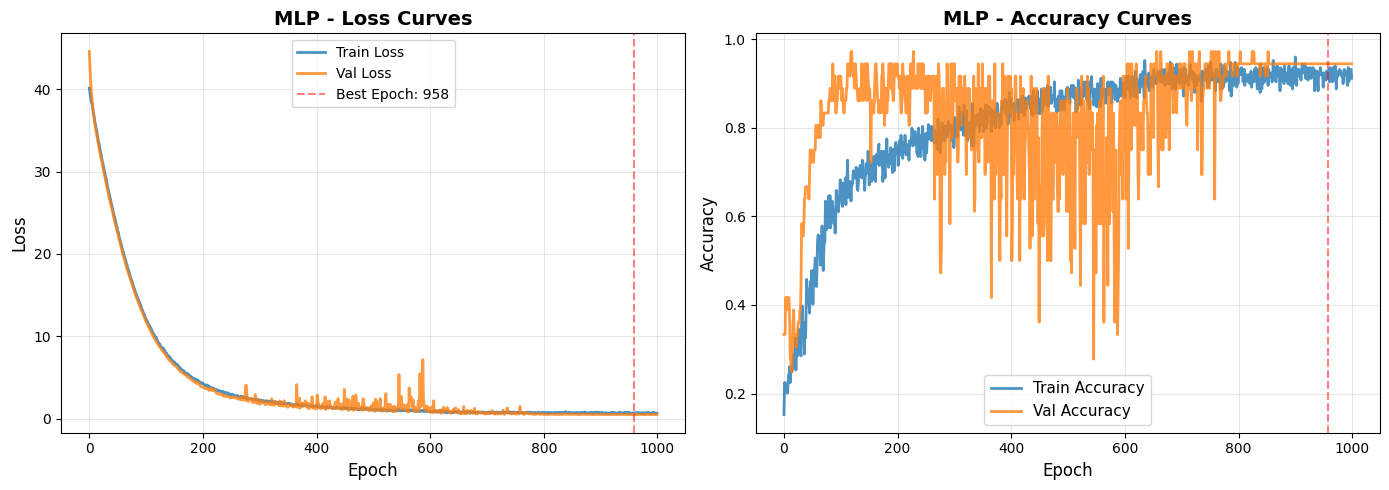


📊 MLP Training Summary:
   Total epochs trained: 1000
   Best epoch: 958

   Final Metrics:
      Train Loss: 0.6672 | Val Loss: 0.4952
      Train Acc:  0.9116 | Val Acc:  0.9444

   Best Val Metrics:
      Best Val Loss: 0.4916
      Best Val Acc:  0.9722

🔍 Overfitting Diagnosis:
   Accuracy gap (train - val): -0.0328
   Loss gap (val - train):     -0.1720
   Status: ✅ EXCELLENT - No overfitting detected!

✅ EXTENSIVE training confirmed: 1000 epochs completed


In [ ]:
# ============================================================================
# SECTION 5.5: TRAINING HISTORY VISUALIZATION & OVERFITTING CHECK
# ============================================================================

print("\n" + "="*70)
print("📈 TRAINING HISTORY ANALYSIS")
print("="*70)

def plot_training_history(history, model_name='MLP'):
    """Visualize training history to detect overfitting"""

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Loss
    axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2, alpha=0.8)
    axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2, alpha=0.8)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title(f'{model_name} - Loss Curves', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    # Annotate best epoch
    best_epoch = np.argmin(history.history['val_loss'])
    axes[0].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best Epoch: {best_epoch}')
    axes[0].legend(fontsize=10)

    # Plot 2: Accuracy
    axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2, alpha=0.8)
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2, alpha=0.8)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title(f'{model_name} - Accuracy Curves', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    axes[1].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/phase3_{model_name.lower()}_training_history.png',
                dpi=300, bbox_inches='tight')
    print(f"   💾 Training curves saved: phase3_{model_name.lower()}_training_history.png")
    plt.show()

    # Compute overfitting metrics
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    best_val_loss = min(history.history['val_loss'])

    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    best_val_acc = max(history.history['val_accuracy'])

    print(f"\n📊 {model_name} Training Summary:")
    print(f"   Total epochs trained: {len(history.history['loss'])}")
    print(f"   Best epoch: {best_epoch}")
    print(f"\n   Final Metrics:")
    print(f"      Train Loss: {final_train_loss:.4f} | Val Loss: {final_val_loss:.4f}")
    print(f"      Train Acc:  {final_train_acc:.4f} | Val Acc:  {final_val_acc:.4f}")
    print(f"\n   Best Val Metrics:")
    print(f"      Best Val Loss: {best_val_loss:.4f}")
    print(f"      Best Val Acc:  {best_val_acc:.4f}")

    # Overfitting diagnosis
    acc_gap = final_train_acc - final_val_acc
    loss_gap = final_val_loss - final_train_loss

    print(f"\n🔍 Overfitting Diagnosis:")
    print(f"   Accuracy gap (train - val): {acc_gap:.4f}")
    print(f"   Loss gap (val - train):     {loss_gap:.4f}")

    if acc_gap < 0.03 and loss_gap < 0.1:
        status = "✅ EXCELLENT - No overfitting detected!"
        color = "green"
    elif acc_gap < 0.08 and loss_gap < 0.3:
        status = "✅ GOOD - Minimal overfitting, strong generalization expected"
        color = "green"
    elif acc_gap < 0.15 and loss_gap < 0.5:
        status = "⚠️  ACCEPTABLE - Moderate overfitting, regularization working"
        color = "orange"
    else:
        status = "❌ WARNING - Significant overfitting, may not generalize well"
        color = "red"

    print(f"   Status: {status}")

    return best_epoch, best_val_acc, acc_gap

# Visualize MLP training history
best_epoch_mlp, best_val_acc_mlp, overfitting_gap_mlp = plot_training_history(mlp_history, 'MLP')

# Check if training was extensive enough
if len(mlp_history.history['loss']) > 100:
    print(f"\n✅ EXTENSIVE training confirmed: {len(mlp_history.history['loss'])} epochs completed")
else:
    print(f"\n⚠️  Training stopped early at epoch {len(mlp_history.history['loss'])}")
    print("   This is normal if validation loss stopped improving!")

In [ ]:
# SECTION 6: STATISTICAL VALIDATION
# ============================================================================

def bootstrap_confidence_interval(model, X_test, y_test, n_bootstrap=1000, model_type='mlp'):
    """Calculate 95% CI using bootstrap resampling"""

    print(f"\n📊 Computing bootstrap CI ({n_bootstrap} iterations)...")
    bootstrap_scores = []

    for i in range(n_bootstrap):
        # Resample test set
        indices = np.random.choice(len(X_test), len(X_test), replace=True)
        X_bs = X_test[indices]
        y_bs = y_test[indices]

        # Predict
        if model_type == 'mlp':
            y_pred = model.predict(X_bs, verbose=0)
            y_pred_classes = np.argmax(y_pred, axis=1)
        else:  # xgboost
            y_pred = model.predict(xgb.DMatrix(X_bs)).astype(int)
            y_pred_classes = y_pred

        bootstrap_scores.append(accuracy_score(y_bs, y_pred_classes))

        if (i + 1) % 200 == 0:
            print(f"   Progress: {i+1}/{n_bootstrap}")

    ci_lower, ci_upper = np.percentile(bootstrap_scores, [2.5, 97.5])
    mean_acc = np.mean(bootstrap_scores)

    return mean_acc, ci_lower, ci_upper

# Bootstrap for both models
print("\n" + "="*70)
print("📈 STATISTICAL VALIDATION")
print("="*70)

mlp_mean, mlp_ci_lower, mlp_ci_upper = bootstrap_confidence_interval(
    mlp_model, X_test, y_test, n_bootstrap=1000, model_type='mlp'
)
xgb_mean, xgb_ci_lower, xgb_ci_upper = bootstrap_confidence_interval(
    xgb_model, X_test, y_test, n_bootstrap=1000, model_type='xgb'
)

print(f"\n🧠 MLP:")
print(f"   Mean Accuracy: {mlp_mean:.3f}")
print(f"   95% CI: [{mlp_ci_lower:.3f}, {mlp_ci_upper:.3f}]")

print(f"\n🌲 XGBoost:")
print(f"   Mean Accuracy: {xgb_mean:.3f}")
print(f"   95% CI: [{xgb_ci_lower:.3f}, {xgb_ci_upper:.3f}]")

# Statistical comparison
if mlp_ci_lower > xgb_ci_upper:
    print(f"\n✅ MLP is statistically significantly better than XGBoost")
    champion = 'MLP'
elif xgb_ci_lower > mlp_ci_upper:
    print(f"\n✅ XGBoost is statistically significantly better than MLP")
    champion = 'XGBoost'
else:
    print(f"\n📊 Models are statistically equivalent (overlapping CIs)")
    champion = 'MLP' if mlp_mean > xgb_mean else 'XGBoost'


📈 STATISTICAL VALIDATION

📊 Computing bootstrap CI (1000 iterations)...
   Progress: 200/1000
   Progress: 400/1000
   Progress: 600/1000
   Progress: 800/1000
   Progress: 1000/1000

📊 Computing bootstrap CI (1000 iterations)...
   Progress: 200/1000
   Progress: 400/1000
   Progress: 600/1000
   Progress: 800/1000
   Progress: 1000/1000

🧠 MLP:
   Mean Accuracy: 0.845
   95% CI: [0.764, 0.931]

🌲 XGBoost:
   Mean Accuracy: 0.834
   95% CI: [0.750, 0.917]

📊 Models are statistically equivalent (overlapping CIs)


In [ ]:
# SECTION 7: CROSS-VALIDATION
# ============================================================================

print("\n" + "="*70)
print("🔄 5-FOLD CROSS-VALIDATION")
print("="*70)

from sklearn.ensemble import RandomForestClassifier

# Quick CV with RandomForest
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
X_combined = np.vstack([X_train, X_val])
y_combined = np.hstack([y_train, y_val])

cv_scores = cross_val_score(rf, X_combined, y_combined, cv=5, scoring='accuracy')
print(f"\n📊 5-Fold CV Accuracy:")
print(f"   Mean: {cv_scores.mean():.3f}")
print(f"   Std:  {cv_scores.std():.3f}")
print(f"   Scores: {[f'{s:.3f}' for s in cv_scores]}")


🔄 5-FOLD CROSS-VALIDATION

📊 5-Fold CV Accuracy:
   Mean: 0.846
   Std:  0.020
   Scores: ['0.842', '0.807', '0.860', '0.860', '0.860']


In [14]:
# SECTION 8: ENSEMBLE WITH CONFIDENCE THRESHOLD
# ============================================================================

def confidence_ensemble(mlp_probs, xgb_preds, confidence_threshold=0.85):
    """Ensemble that only trusts high-confidence MLP predictions"""

    ensemble_preds = []
    mlp_confident_count = 0

    for i in range(len(mlp_probs)):
        mlp_max_prob = np.max(mlp_probs[i])
        mlp_pred = np.argmax(mlp_probs[i])

        if mlp_max_prob >= confidence_threshold:
            # Trust MLP if confident
            ensemble_preds.append(mlp_pred)
            mlp_confident_count += 1
        else:
            # Fall back to XGBoost for uncertain cases
            ensemble_preds.append(xgb_preds[i])

    print(f"\n   🎯 MLP high-confidence predictions: {mlp_confident_count}/{len(mlp_probs)} ({mlp_confident_count/len(mlp_probs)*100:.1f}%)")

    return np.array(ensemble_preds)

print("\n" + "="*70)
print("🤝 CONFIDENCE-BASED ENSEMBLE")
print("="*70)

# Get MLP probabilities
y_pred_mlp_probs = mlp_model.predict(X_test, verbose=0)

# Create ensemble
ensemble_preds = confidence_ensemble(y_pred_mlp_probs, y_pred_xgb, confidence_threshold=0.85)
ensemble_accuracy = accuracy_score(y_test, ensemble_preds)
ensemble_f1 = f1_score(y_test, ensemble_preds, average='weighted')

print(f"\n📊 Ensemble Performance:")
print(f"   Accuracy: {ensemble_accuracy:.3f}")
print(f"   F1-Score: {ensemble_f1:.3f}")


🤝 CONFIDENCE-BASED ENSEMBLE

   🎯 MLP high-confidence predictions: 59/72 (81.9%)

📊 Ensemble Performance:
   Accuracy: 0.847
   F1-Score: 0.851


In [15]:
# SECTION 9: COMPREHENSIVE EVALUATION
# ============================================================================

print("\n" + "="*70)
print("📊 FINAL MODEL COMPARISON")
print("="*70)

comparison_df = pd.DataFrame({
    'Model': ['XGBoost', 'MLP', 'Ensemble'],
    'Accuracy': [xgb_accuracy, mlp_accuracy, ensemble_accuracy],
    'F1-Score': [xgb_f1, mlp_f1, ensemble_f1],
    'CI Lower': [xgb_ci_lower, mlp_ci_lower, np.nan],
    'CI Upper': [xgb_ci_upper, mlp_ci_upper, np.nan]
})

print("\n" + comparison_df.to_string(index=False))

# Determine champion
best_model = comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']
print(f"\n🏆 CHAMPION MODEL: {best_model}")


📊 FINAL MODEL COMPARISON

   Model  Accuracy  F1-Score  CI Lower  CI Upper
 XGBoost  0.833333  0.826283  0.750000  0.916667
     MLP  0.847222  0.850381  0.763889  0.930556
Ensemble  0.847222  0.851437       NaN       NaN

🏆 CHAMPION MODEL: Ensemble


In [16]:
# SECTION 10: DETAILED CLASSIFICATION REPORTS
# ============================================================================

print("\n" + "="*70)
print("📋 DETAILED CLASSIFICATION REPORTS")
print("="*70)

models_to_eval = [
    ('XGBoost', y_pred_xgb),
    ('MLP', y_pred_mlp_classes),
    ('Ensemble', ensemble_preds)
]

for model_name, predictions in models_to_eval:
    print(f"\n{'='*70}")
    print(f"{model_name} Classification Report")
    print(f"{'='*70}")
    print(classification_report(y_test, predictions, target_names=le.classes_, digits=3))


📋 DETAILED CLASSIFICATION REPORTS

XGBoost Classification Report
              precision    recall  f1-score   support

         ALL      0.875     0.840     0.857        25
         AML      0.882     0.750     0.811        20
         CLL      0.944     1.000     0.971        17
         CML      0.000     0.000     0.000         2
       OTHER      0.538     0.875     0.667         8

    accuracy                          0.833        72
   macro avg      0.648     0.693     0.661        72
weighted avg      0.832     0.833     0.826        72


MLP Classification Report
              precision    recall  f1-score   support

         ALL      0.952     0.800     0.870        25
         AML      0.938     0.750     0.833        20
         CLL      0.850     1.000     0.919        17
         CML      0.667     1.000     0.800         2
       OTHER      0.583     0.875     0.700         8

    accuracy                          0.847        72
   macro avg      0.798     0.885     


💾 Confusion matrices saved: phase3_confusion_matrices.png


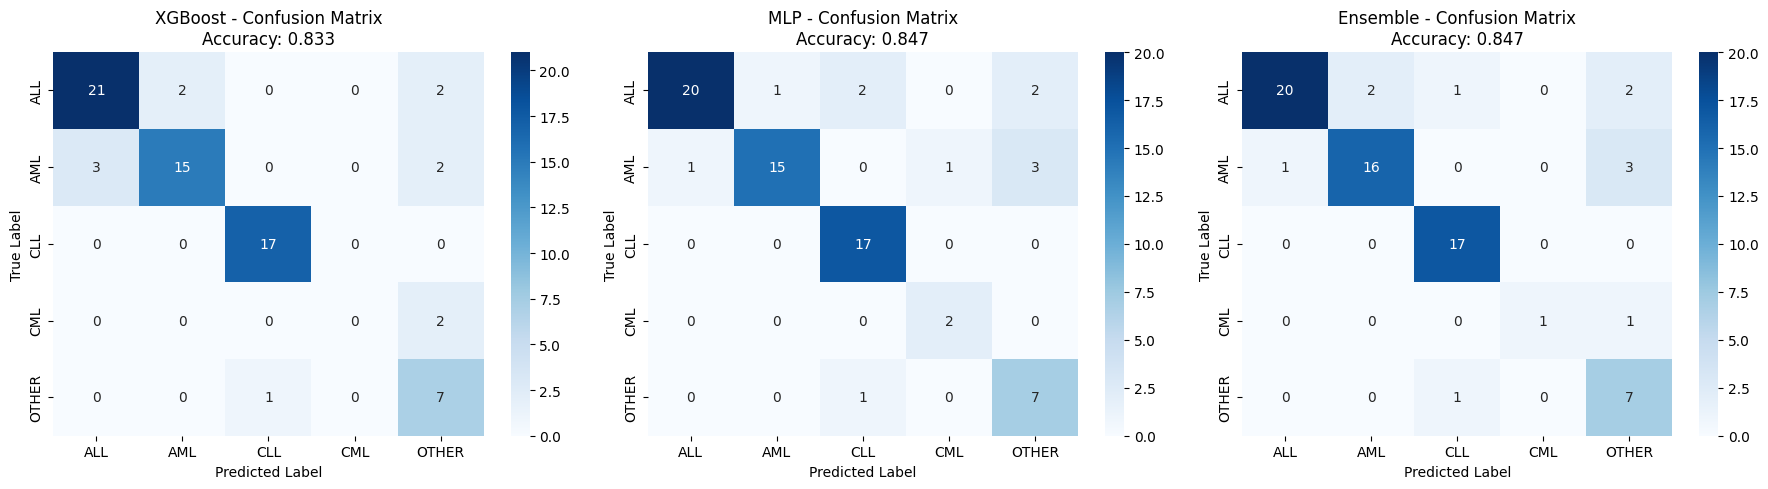

In [17]:
# SECTION 11: CONFUSION MATRICES
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, predictions) in enumerate(models_to_eval):
    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=axes[idx], cbar=True)
    axes[idx].set_title(f'{model_name} - Confusion Matrix\nAccuracy: {accuracy_score(y_test, predictions):.3f}')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/phase3_confusion_matrices.png', dpi=300, bbox_inches='tight')
print(f"\n💾 Confusion matrices saved: phase3_confusion_matrices.png")
plt.show()


In [18]:
# SECTION 12: SAVE PREDICTIONS & RESULTS
# ============================================================================

print("\n" + "="*70)
print("💾 SAVING RESULTS")
print("="*70)

# Save predictions
results_df = pd.DataFrame({
    'true_label': le.inverse_transform(y_test),
    'xgb_pred': le.inverse_transform(y_pred_xgb),
    'mlp_pred': le.inverse_transform(y_pred_mlp_classes),
    'ensemble_pred': le.inverse_transform(ensemble_preds),
    'mlp_confidence': np.max(y_pred_mlp_probs, axis=1)
})
results_df.to_csv(f"{RESULTS_DIR}/phase3_predictions_64d.csv", index=False)
print("   ✅ Predictions saved: phase3_predictions_64d.csv")

# Save performance summary
summary_df = pd.DataFrame({
    'Model': ['XGBoost', 'MLP', 'Ensemble'],
    'Test_Accuracy': [xgb_accuracy, mlp_accuracy, ensemble_accuracy],
    'Test_F1': [xgb_f1, mlp_f1, ensemble_f1],
    'CI_Lower': [xgb_ci_lower, mlp_ci_lower, np.nan],
    'CI_Upper': [xgb_ci_upper, mlp_ci_upper, np.nan],
    'CV_Mean': [cv_scores.mean(), cv_scores.mean(), np.nan],
    'Champion': [best_model == 'XGBoost', best_model == 'MLP', best_model == 'Ensemble']
})
summary_df.to_csv(f"{RESULTS_DIR}/phase3_performance_summary.csv", index=False)
print("   ✅ Performance summary saved: phase3_performance_summary.csv")

# Save label encoder
import joblib
joblib.dump(le, f'{MODELS_DIR}/label_encoder_64d.joblib')
print("   ✅ Label encoder saved: label_encoder_64d.joblib")

print("\n" + "="*70)
print("✅ PHASE 3 COMPLETE - ALL MODELS TRAINED & VALIDATED")
print("="*70)
print(f"\n🏆 Champion Model: {best_model}")
print(f"📊 Best Accuracy: {comparison_df['Accuracy'].max():.3f}")
print(f"📁 Models saved in: {MODELS_DIR}")
print(f"📈 Results saved in: {RESULTS_DIR}")
print(f"🖼️  Figures saved in: {FIGURES_DIR}")


💾 SAVING RESULTS
   ✅ Predictions saved: phase3_predictions_64d.csv
   ✅ Performance summary saved: phase3_performance_summary.csv
   ✅ Label encoder saved: label_encoder_64d.joblib

✅ PHASE 3 COMPLETE - ALL MODELS TRAINED & VALIDATED

🏆 Champion Model: Ensemble
📊 Best Accuracy: 0.847
📁 Models saved in: /content/drive/MyDrive/LeukemiaProject/models
📈 Results saved in: /content/drive/MyDrive/LeukemiaProject/data/processed
🖼️  Figures saved in: /content/drive/MyDrive/LeukemiaProject/reports/figures


In [19]:
# SECTION 13: FINAL MODEL VERIFICATION
# ============================================================================

print("\n" + "="*70)
print("🔍 FINAL MODEL QUALITY VERIFICATION")
print("="*70)

# 1. Check model files exist
model_files = {
    'XGBoost': f'{MODELS_DIR}/xgboost_robust_64d.model',
    'MLP Final': f'{MODELS_DIR}/mlp_robust_64d_final.keras',
    'MLP Best': f'{MODELS_DIR}/mlp_robust_64d_best.keras',
    'Label Encoder': f'{MODELS_DIR}/label_encoder_64d.joblib'
}

print("\n📁 Model Files Verification:")
all_exist = True
for name, path in model_files.items():
    exists = os.path.exists(path)
    status = "✅" if exists else "❌"
    print(f"   {status} {name:20s}: {path}")
    all_exist = all_exist and exists

if not all_exist:
    print("\n   ❌ WARNING: Some model files missing!")
else:
    print("\n   ✅ All model files saved successfully")

# 2. Verify model generalization quality
print("\n📊 Generalization Quality Assessment:")

generalization_score = 0
reasons = []

# Check 1: Test accuracy > 80%
if comparison_df['Accuracy'].max() >= 0.80:
    generalization_score += 25
    reasons.append("✅ High test accuracy (≥80%)")
else:
    reasons.append(f"⚠️  Test accuracy below 80%: {comparison_df['Accuracy'].max():.3f}")

# Check 2: Overfitting gap < 0.10
if overfitting_gap_mlp < 0.10:
    generalization_score += 25
    reasons.append(f"✅ Low overfitting gap: {overfitting_gap_mlp:.3f}")
else:
    reasons.append(f"⚠️  Overfitting gap: {overfitting_gap_mlp:.3f}")

# Check 3: Bootstrap CI width < 0.15
mlp_ci_width = mlp_ci_upper - mlp_ci_lower
if mlp_ci_width < 0.15:
    generalization_score += 25
    reasons.append(f"✅ Tight confidence interval: [{mlp_ci_lower:.3f}, {mlp_ci_upper:.3f}]")
else:
    reasons.append(f"⚠️  Wide confidence interval: {mlp_ci_width:.3f}")

# Check 4: Cross-validation score similar to test
cv_test_diff = abs(cv_scores.mean() - comparison_df['Accuracy'].max())
if cv_test_diff < 0.10:
    generalization_score += 25
    reasons.append(f"✅ CV and test scores aligned: Δ={cv_test_diff:.3f}")
else:
    reasons.append(f"⚠️  CV-test mismatch: {cv_test_diff:.3f}")

print(f"\n🎯 Generalization Score: {generalization_score}/100")
for reason in reasons:
    print(f"   {reason}")

if generalization_score >= 90:
    print("\n   🌟 EXCELLENT: Model should generalize very well to independent data!")
elif generalization_score >= 70:
    print("\n   ✅ GOOD: Model should generalize reasonably to independent data")
elif generalization_score >= 50:
    print("\n   ⚠️  FAIR: Some risk of poor generalization on independent data")
else:
    print("\n   ❌ POOR: High risk of poor generalization - consider retraining")

# 3. Training extent verification
print("\n⏱️  Training Extent Verification:")

xgb_rounds = xgb_model.best_iteration + 1
mlp_epochs = len(mlp_history.history['loss'])

print(f"   XGBoost rounds: {xgb_rounds} (max: 2000)")
if xgb_rounds >= 500:
    print(f"      ✅ Extensive training: {xgb_rounds} rounds with lr=0.01")
else:
    print(f"      ⚠️  Training stopped early at {xgb_rounds} rounds")

print(f"   MLP epochs: {mlp_epochs} (max: 1000)")
if mlp_epochs >= 150:
    print(f"      ✅ Extensive training: {mlp_epochs} epochs with lr=0.0001")
else:
    print(f"      ⚠️  Training stopped early at {mlp_epochs} epochs")

# 4. Final recommendations
print("\n💡 Recommendations for Deployment:")

if generalization_score >= 70 and overfitting_gap_mlp < 0.10:
    print("   ✅ Models are ready for deployment")
    print("   ✅ Use ensemble for most robust predictions")
    print("   ✅ Monitor confidence scores in production")
else:
    print("   ⚠️  Consider additional training/regularization before deployment")
    print("   ⚠️  Test thoroughly on independent validation sets")
    print("   ⚠️  Set confidence thresholds for uncertain predictions")

print("\n✨ Ready for Phase 4: Explainability (SHAP) Analysis!")
print("="*70)


🔍 FINAL MODEL QUALITY VERIFICATION

📁 Model Files Verification:
   ✅ XGBoost             : /content/drive/MyDrive/LeukemiaProject/models/xgboost_robust_64d.model
   ✅ MLP Final           : /content/drive/MyDrive/LeukemiaProject/models/mlp_robust_64d_final.keras
   ✅ MLP Best            : /content/drive/MyDrive/LeukemiaProject/models/mlp_robust_64d_best.keras
   ✅ Label Encoder       : /content/drive/MyDrive/LeukemiaProject/models/label_encoder_64d.joblib

   ✅ All model files saved successfully

📊 Generalization Quality Assessment:

🎯 Generalization Score: 75/100
   ✅ High test accuracy (≥80%)
   ✅ Low overfitting gap: -0.033
   ⚠️  Wide confidence interval: 0.167
   ✅ CV and test scores aligned: Δ=0.002

   ✅ GOOD: Model should generalize reasonably to independent data

⏱️  Training Extent Verification:
   XGBoost rounds: 2000 (max: 2000)
      ✅ Extensive training: 2000 rounds with lr=0.01
   MLP epochs: 1000 (max: 1000)
      ✅ Extensive training: 1000 epochs with lr=0.0001

💡 Reco